# QUBO Portfolio Demo

This notebook demonstrates the Phase 2 QUBO portfolio pipeline. It uses the existing backend functions to fetch market data, compute return and risk inputs, compile a binary portfolio selection problem into QUBO form, solve it by brute force, visualize the result, and verify the equivalent Ising energy.

## 1. Setup

Add the project root to `sys.path` so the notebook can run from the `notebooks/` folder, then import the backend functions used in the demo.

In [15]:
from itertools import product
from pathlib import Path
import matplotlib.pyplot as plt
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.data.covariance import compute_covariance_matrix
from backend.data.market_data import fetch_price_data
from backend.data.returns import compute_annualized_returns, compute_daily_returns
from backend.quantum.bruteforce_solver import evaluate_qubo, solve_qubo_bruteforce
from backend.quantum.ising import evaluate_ising, qubo_to_ising
from backend.quantum.qubo import build_portfolio_qubo
from backend.quantum.qubo_visualization import (
    plot_qubo_heatmap,
    plot_qubo_solution_landscape,
)

pd.options.display.float_format = "{:.6f}".format

## 2. Define the Asset Universe

The demo uses five ETFs: broad U.S. equities, Nasdaq growth exposure, dividend growth equities, long-term Treasuries, and gold.

In [16]:
tickers = ["SPY", "QQQ", "VIG", "TLT", "GLD"]
tickers

['SPY', 'QQQ', 'VIG', 'TLT', 'GLD']

## 3. Build Phase 1 Inputs

Fetch historical prices, compute daily returns, annualized expected returns, and the annualized covariance matrix. These are the same portfolio inputs used by the classical pipeline.

In [17]:
prices = fetch_price_data(tickers, period="5y")
daily_returns = compute_daily_returns(prices)
expected_returns = compute_annualized_returns(daily_returns)
covariance_matrix = compute_covariance_matrix(daily_returns)

prices.tail()

,SPY,QQQ,VIG,TLT,GLD
Date,,,,,
2026-04-28,711.690002,657.549988,225.350006,86.052246,421.910004
2026-04-29,711.580017,661.570007,225.630005,85.384705,417.410004
2026-04-30,718.659973,667.739990,228.710007,85.305000,423.660004
2026-05-01,720.650024,674.150024,228.440002,85.610001,423.179993
2026-05-04,717.650024,671.559998,227.440002,84.960197,415.200012


## 4. Inspect Return and Risk Inputs

The QUBO compiler uses expected returns as the reward term and covariance as the risk term.

In [18]:
display(expected_returns.rename("expected_return"))
display(covariance_matrix)

SPY    0.137984
QQQ    0.173702
VIG    0.106611
TLT   -0.053577
GLD    0.199546
Name: expected_return, dtype: float64

,SPY,QQQ,VIG,TLT,GLD
SPY,0.029212,0.036452,0.022926,0.001895,0.003936
QQQ,0.036452,0.050223,0.026369,0.002540,0.004649
VIG,0.022926,0.026369,0.020396,0.002127,0.003425
TLT,0.001895,0.002540,0.002127,0.025150,0.006011
GLD,0.003936,0.004649,0.003425,0.006011,0.032041


## 5. Compile the Binary Selection Problem

This demo chooses exactly `K = 3` assets. Selected assets are treated as equally weighted, and the cardinality penalty discourages portfolios that select any number other than three.

In [19]:
num_assets_to_select = 3
risk_aversion = 1.0
penalty_strength = 10.0

Q = build_portfolio_qubo(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    num_assets_to_select=num_assets_to_select,
    risk_aversion=risk_aversion,
    penalty_strength=penalty_strength,
)

Q

,SPY,QQQ,VIG,TLT,GLD
SPY,-50.042749,10.004050,10.002547,10.000211,10.000437
QQQ,10.004050,-50.052320,10.002930,10.000282,10.000517
VIG,10.002547,10.002930,-50.033271,10.000236,10.000381
TLT,10.000211,10.000282,10.000236,-49.979347,10.000668
GLD,10.000437,10.000517,10.000381,10.000668,-50.062955


## 6. Solve the QUBO by Brute Force

For five assets, exhaustive search is small enough to use as a ground-truth solver. This checks every binary selection and returns the one with the lowest QUBO objective.

In [20]:
best_selection, best_objective_value = solve_qubo_bruteforce(Q)
selected_assets = best_selection[best_selection == 1].index.tolist()

display(best_selection.rename("selected"))
display(pd.Series(selected_assets, name="selected_assets"))
best_objective_value

SPY    1
QQQ    1
VIG    0
TLT    0
GLD    1
Name: selected, dtype: int64

0    SPY
1    QQQ
2    GLD
Name: selected_assets, dtype: str

-90.14801600491269

## 7. Visualize the QUBO Matrix

The heatmap makes diagonal return and penalty terms, plus off-diagonal covariance and pairwise penalty terms, easier to inspect.

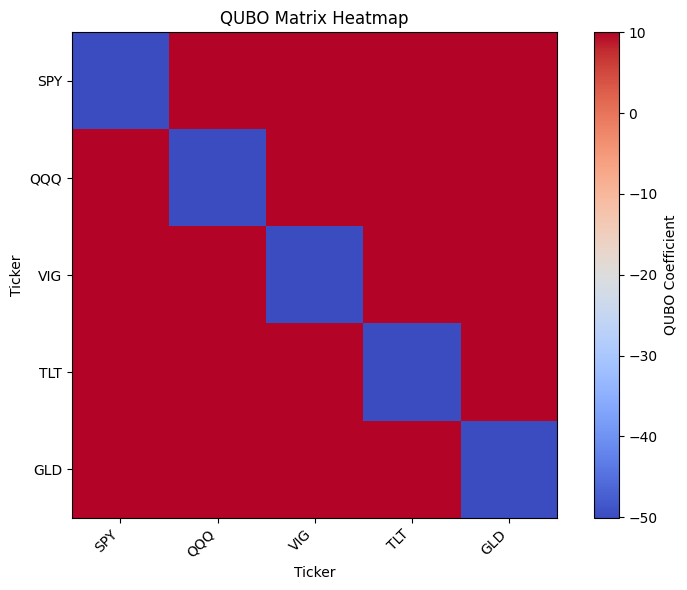

In [21]:
fig =plot_qubo_heatmap(Q)
display(fig)
plt.close(fig)

## 8. Build and Visualize the Solution Landscape

The landscape evaluates every candidate bitstring and plots objective values across the search space. This is practical here because five assets produce only `2^5 = 32` candidates.

,bitstring,objective_value,num_selected
0,11001,-90.148016,3
1,01101,-90.140892,3
2,10101,-90.132244,3
3,11100,-90.109285,3
4,01011,-90.091689,3
5,10011,-90.082419,3
6,00111,-90.073003,3
7,11010,-90.065330,3
8,01110,-90.058041,3
9,10110,-90.049378,3


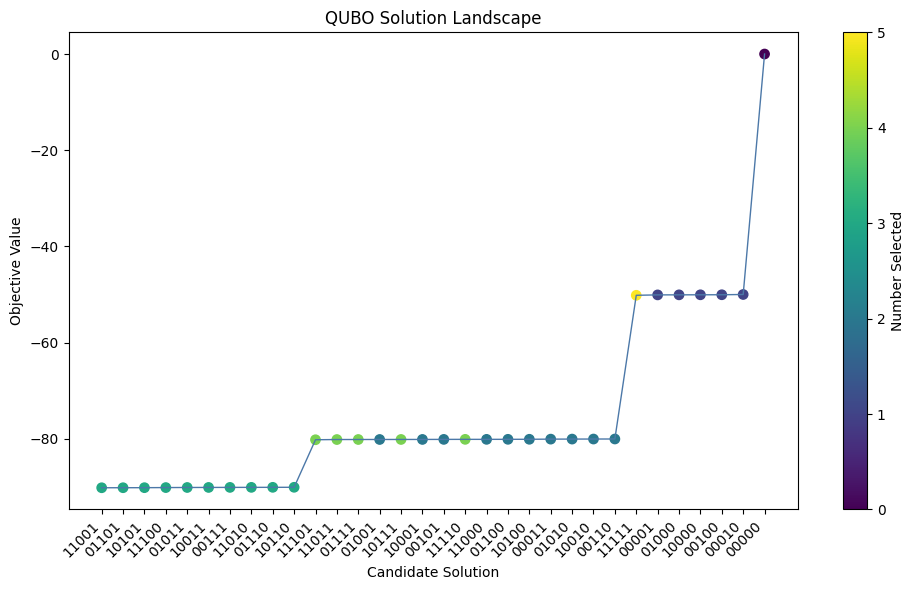

In [22]:
solution_rows = []
for values in product([0, 1], repeat=len(Q.index)):
    selection = pd.Series(values, index=Q.index)
    bitstring = "".join(str(value) for value in values)
    solution_rows.append(
        {
            "bitstring": bitstring,
            "objective_value": evaluate_qubo(selection, Q),
            "num_selected": int(selection.sum()),
        }
    )

solutions = pd.DataFrame(solution_rows).sort_values("objective_value").reset_index(drop=True)
display(solutions.head(10))
fig = plot_qubo_solution_landscape(solutions)
display(fig)
plt.close(fig)

## 9. Convert the QUBO to Ising Form

The Ising representation rewrites the same objective using spin variables `z_i` in `{-1, +1}`. This is the form that connects naturally to later Hamiltonian-based quantum workflows.

In [23]:
h, J, offset = qubo_to_ising(Q)

display(h)
display(J)
offset

SPY   5.017752
QQQ   5.022271
VIG   5.013588
TLT   4.988975
GLD   5.030476
Name: h, dtype: float64

,SPY,QQQ,VIG,TLT,GLD
SPY,0.000000,5.002025,5.001274,5.000105,5.000219
QQQ,5.002025,0.000000,5.001465,5.000141,5.000258
VIG,5.001274,5.001465,0.000000,5.000118,5.000190
TLT,5.000105,5.000141,5.000118,0.000000,5.000334
GLD,5.000219,5.000258,5.000190,5.000334,0.000000


-75.07919147846032

## 10. Verify QUBO and Ising Energy Consistency

The mapping `x_i = (1 - z_i) / 2` is equivalent to `z_i = 1 - 2x_i`. The same portfolio should have the same energy in both representations, up to numerical tolerance.

In [24]:
qubo_energy = evaluate_qubo(best_selection, Q)
best_spins = 1 - 2 * best_selection
ising_energy = evaluate_ising(best_spins, h, J, offset)
energy_difference = abs(qubo_energy - ising_energy)

energy_check = pd.Series(
    {
        "qubo_energy": qubo_energy,
        "ising_energy": ising_energy,
        "absolute_difference": energy_difference,
        "matches_tolerance": energy_difference < 1e-9,
    }
)

display(best_spins.rename("spin"))
energy_check

SPY   -1
QQQ   -1
VIG    1
TLT    1
GLD   -1
Name: spin, dtype: int64

qubo_energy           -90.148016
ising_energy          -90.148016
absolute_difference     0.000000
matches_tolerance           True
dtype: object

## Summary

This notebook completes the Phase 2 classical QUBO pipeline: market data becomes return and covariance inputs, those inputs become a binary QUBO, brute force provides a small-system optimum, visualization helps inspect the matrix and landscape, and Ising conversion verifies the representation needed before future QAOA work.